In [1]:
library(plot3D)
library(tidyr)
library(tidyverse)
library(scales)
library(latex2exp)
library(cowplot)
library(ggh4x)
library(ggpubr)
library(patchwork)

library(scales)
library(reticulate)
library(RColorBrewer)
library(stringr)
library(dplyr)
library(ggplot2)
library(gridExtra)

Warning message in fun(libname, pkgname):
“couldn't connect to display "/private/tmp/com.apple.launchd.KNVZdiQDdw/org.xquartz:0"”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ purrr     1.0.2
✔ forcats   1.0.0     ✔ readr     2.1.5
✔ ggplot2   3.5.1     ✔ stringr   1.5.1
✔ lubridate 1.9.4     ✔ tibble    3.2.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ purrr::%||%()   masks base::%||%()
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor



Attaching package: ‘cowplot’


The following object is masked from ‘package:lubridate’:

    stamp



Attaching package: ‘ggpubr’


The following object is maske

In [2]:
setwd(dirname(dirname(getwd())))
root_path <- getwd()

In [3]:
source("./MethodsEvaluation/results_processing_for_analysis.R")
source("./Pysindy/utils/pysindy_results_processing_for_analysis.R")

In [4]:
nbfigsize <- function(width, height) {
    options(
        repr.plot.width = width,
        repr.plot.height = height,
        repr.plot.res = 300
    )
}

nbfigsize(
    width = 12,
    height = 11
)

## Generate the computational time table for ARGOS family methods


In [5]:
dynamical_system_name <- "lorenz"
experiment_name_list <- list("argos-alasso", "bayesian-alasso-ro")
method_list <- list("argos-alasso", "bayesian-alasso-ro")
function_number <- 3
exp_n <- TRUE
typical_pattern <- "snr49"
num_init <- 100

In [6]:
total_results_summary_df <- enhance_total_results_summary_df(
    root_path = root_path,
    experiment_name_list = experiment_name_list,
    method_list = method_list,
    function_number = function_number,
    num_init = num_init,
    dynamical_system_name = dynamical_system_name,
    exp_n = exp_n,
    typical_pattern = typical_pattern
)
head(total_results_summary_df)

[1] "/Users/yuzhengzhang/Documents-Local/Code-Local/Bayesian-ARGOS/Experiments/argos-alasso/lorenz/results/lorenz_1_e2_e3_bo2000_se100_alasso_ridge_snr49.RData"
[2] "/Users/yuzhengzhang/Documents-Local/Code-Local/Bayesian-ARGOS/Experiments/argos-alasso/lorenz/results/lorenz_1_e3_e4_bo2000_se100_alasso_ridge_snr49.RData"
[3] "/Users/yuzhengzhang/Documents-Local/Code-Local/Bayesian-ARGOS/Experiments/argos-alasso/lorenz/results/lorenz_1_e4_e5_bo2000_se100_alasso_ridge_snr49.RData"
[1] "/Users/yuzhengzhang/Documents-Local/Code-Local/Bayesian-ARGOS/Experiments/argos-alasso/lorenz/results/lorenz_2_e2_e3_bo2000_se100_alasso_ridge_snr49.RData"
[2] "/Users/yuzhengzhang/Documents-Local/Code-Local/Bayesian-ARGOS/Experiments/argos-alasso/lorenz/results/lorenz_2_e3_e4_bo2000_se100_alasso_ridge_snr49.RData"
[3] "/Users/yuzhengzhang/Documents-Local/Code-Local/Bayesian-ARGOS/Experiments/argos-alasso/lorenz/results/lorenz_2_e4_e5_bo2000_se100_alasso_ridge_snr49.RData"
[1] "/Users/yuzhengzhang/Documents

,run_id,list_name,eta,function_id,method,num_of_identified_terms,run_time,function_indicator,case_id,n_running_id
,<chr>,<chr>,<chr>,<int>,<chr>,<int>,<dbl>,<chr>,<chr>,<chr>
1,1.1.1,n=1e+2,2,1,alasso,1,34.37162,xdot,1-2-1,2-1
2,1.1.2,n=1e+2,2,1,alasso,2,36.39715,xdot,1-2-2,2-2
3,1.1.3,n=1e+2,2,1,alasso,0,35.73503,xdot,1-2-3,2-3
4,1.1.4,n=1e+2,2,1,alasso,1,33.13522,xdot,1-2-4,2-4
5,1.1.5,n=1e+2,2,1,alasso,0,30.31232,xdot,1-2-5,2-5
6,1.1.6,n=1e+2,2,1,alasso,1,33.25113,xdot,1-2-6,2-6


In [7]:
methods_running_time_table <- create_time_complexity_table(
    total_results_summary_df = total_results_summary_df,
    type_1_method_list = c("alasso"),
    type_1_method_cpu_number = 20,
    type_2_method_list = c("bayesian-argos", "bayesian-alasso-ro"),
    type_2_method_cpu_number = 4
)
head(methods_running_time_table)

,n_running_id,run_time,eta,method
,<chr>,<dbl>,<chr>,<chr>
alasso.1,2-1,1852.171,2,alasso
alasso.2,2-10,1690.542,2,alasso
alasso.3,2-100,1602.689,2,alasso
alasso.4,2-11,1695.187,2,alasso
alasso.5,2-12,1661.613,2,alasso
alasso.6,2-13,1698.561,2,alasso


## Generate the computational time table for SINDy methods


In [8]:
pysindy_path <- file.path(getwd(), "Pysindy")

In [9]:
total_results_summary_df_sindy <- enhance_total_results_summary_df_py(
    root_path = pysindy_path,
    experiment_name_list = c("pysindy"),
    method_list = c("pysindy"),
    num_init = num_init,
    dynamical_system_name = dynamical_system_name,
    exp_n = exp_n,
    typical_pattern = typical_pattern
)

[1] "/Users/yuzhengzhang/Documents-Local/Code-Local/Bayesian-ARGOS/Pysindy/exp/lorenz/results/lorenz_e2_e3_se100_snr49.RData"
[2] "/Users/yuzhengzhang/Documents-Local/Code-Local/Bayesian-ARGOS/Pysindy/exp/lorenz/results/lorenz_e3_e4_se100_snr49.RData"
[3] "/Users/yuzhengzhang/Documents-Local/Code-Local/Bayesian-ARGOS/Pysindy/exp/lorenz/results/lorenz_e4_e5_se100_snr49.RData"
[1] 1
[1] 100
[1] 2
[1] 100
[1] 3
[1] 100
[1] 4
[1] 100
[1] 5
[1] 100
[1] 6
[1] 100
[1] 7
[1] 100
[1] 8
[1] 100
[1] 9
[1] 100
[1] 10
[1] 100
[1] 11
[1] 100
[1] 12
[1] 100
[1] 13
[1] 100
[1] 14
[1] 100
[1] 15
[1] 100
[1] 16
[1] 100
[1] 17
[1] 100
[1] 18
[1] 100
[1] 19
[1] 100
[1] 20
[1] 100
[1] 21
[1] 100
[1] 22
[1] 100
[1] 23
[1] 100
[1] 24
[1] 100
[1] 25
[1] 100
[1] 26
[1] 100
[1] 27
[1] 100
[1] 28
[1] 100
[1] 29
[1] 100
[1] 30
[1] 100
[1] 31
[1] 100


In [10]:
sindy_running_time_table <- create_time_complexity_table_py(
    total_results_summary_df = total_results_summary_df_sindy,
    type_1_method_list = c("alasso"),
    type_1_method_cpu_number = 20,
    type_2_method_list = c("bayesian-argos", "bayesian-alasso-ro"),
    type_2_method_cpu_number = 4,
    type_3_method_list = c("pysindy"),
    type_3_method_cpu_number = 1
)
head(sindy_running_time_table)

,n_running_id,run_time,eta,method
,<chr>,<dbl>,<chr>,<chr>
pysindy.1,2-1,0.156013966,2,pysindy
pysindy.2,2-10,0.156255484,2,pysindy
pysindy.3,2-100,0.009609699,2,pysindy
pysindy.4,2-11,0.152208328,2,pysindy
pysindy.5,2-12,0.152150154,2,pysindy
pysindy.6,2-13,0.009924412,2,pysindy


In [11]:
total_running_time_table <- rbind(
    methods_running_time_table,
    sindy_running_time_table
)
total_running_time_table <- rename_method_names(total_running_time_table)
tail(total_running_time_table)

,n_running_id,run_time,eta,method
,<chr>,<dbl>,<chr>,<chr>
pysindy.3095,5-94,0.5819693,5,SINDy
pysindy.3096,5-95,0.7018843,5,SINDy
pysindy.3097,5-96,0.6775393,5,SINDy
pysindy.3098,5-97,0.4772859,5,SINDy
pysindy.3099,5-98,0.4652846,5,SINDy
pysindy.3100,5-99,0.4642460,5,SINDy


## Plot the total computational plot


In [12]:
selected_eta_list <- seq(3, 5, by = 0.5)
methods_running_time_table <- total_running_time_table %>%
  dplyr::filter(eta %in% selected_eta_list)


methods_running_time_table_argos <- methods_running_time_table %>%
  dplyr::filter(method == "ARGOS")
methods_running_time_table_argos$eta <- as.numeric(
  methods_running_time_table_argos$eta
) *
  2 -
  5

methods_running_time_table_bayesian_argos <- methods_running_time_table %>%
  dplyr::filter(method == "Bayesian-ARGOS")
methods_running_time_table_bayesian_argos$eta <- as.numeric(
  methods_running_time_table_bayesian_argos$eta
) *
  2 -
  5

methods_running_time_table_sindy <- methods_running_time_table %>%
  dplyr::filter(method == "SINDy")
methods_running_time_table_sindy$eta <- as.numeric(
  methods_running_time_table_sindy$eta
) *
  2 -
  5

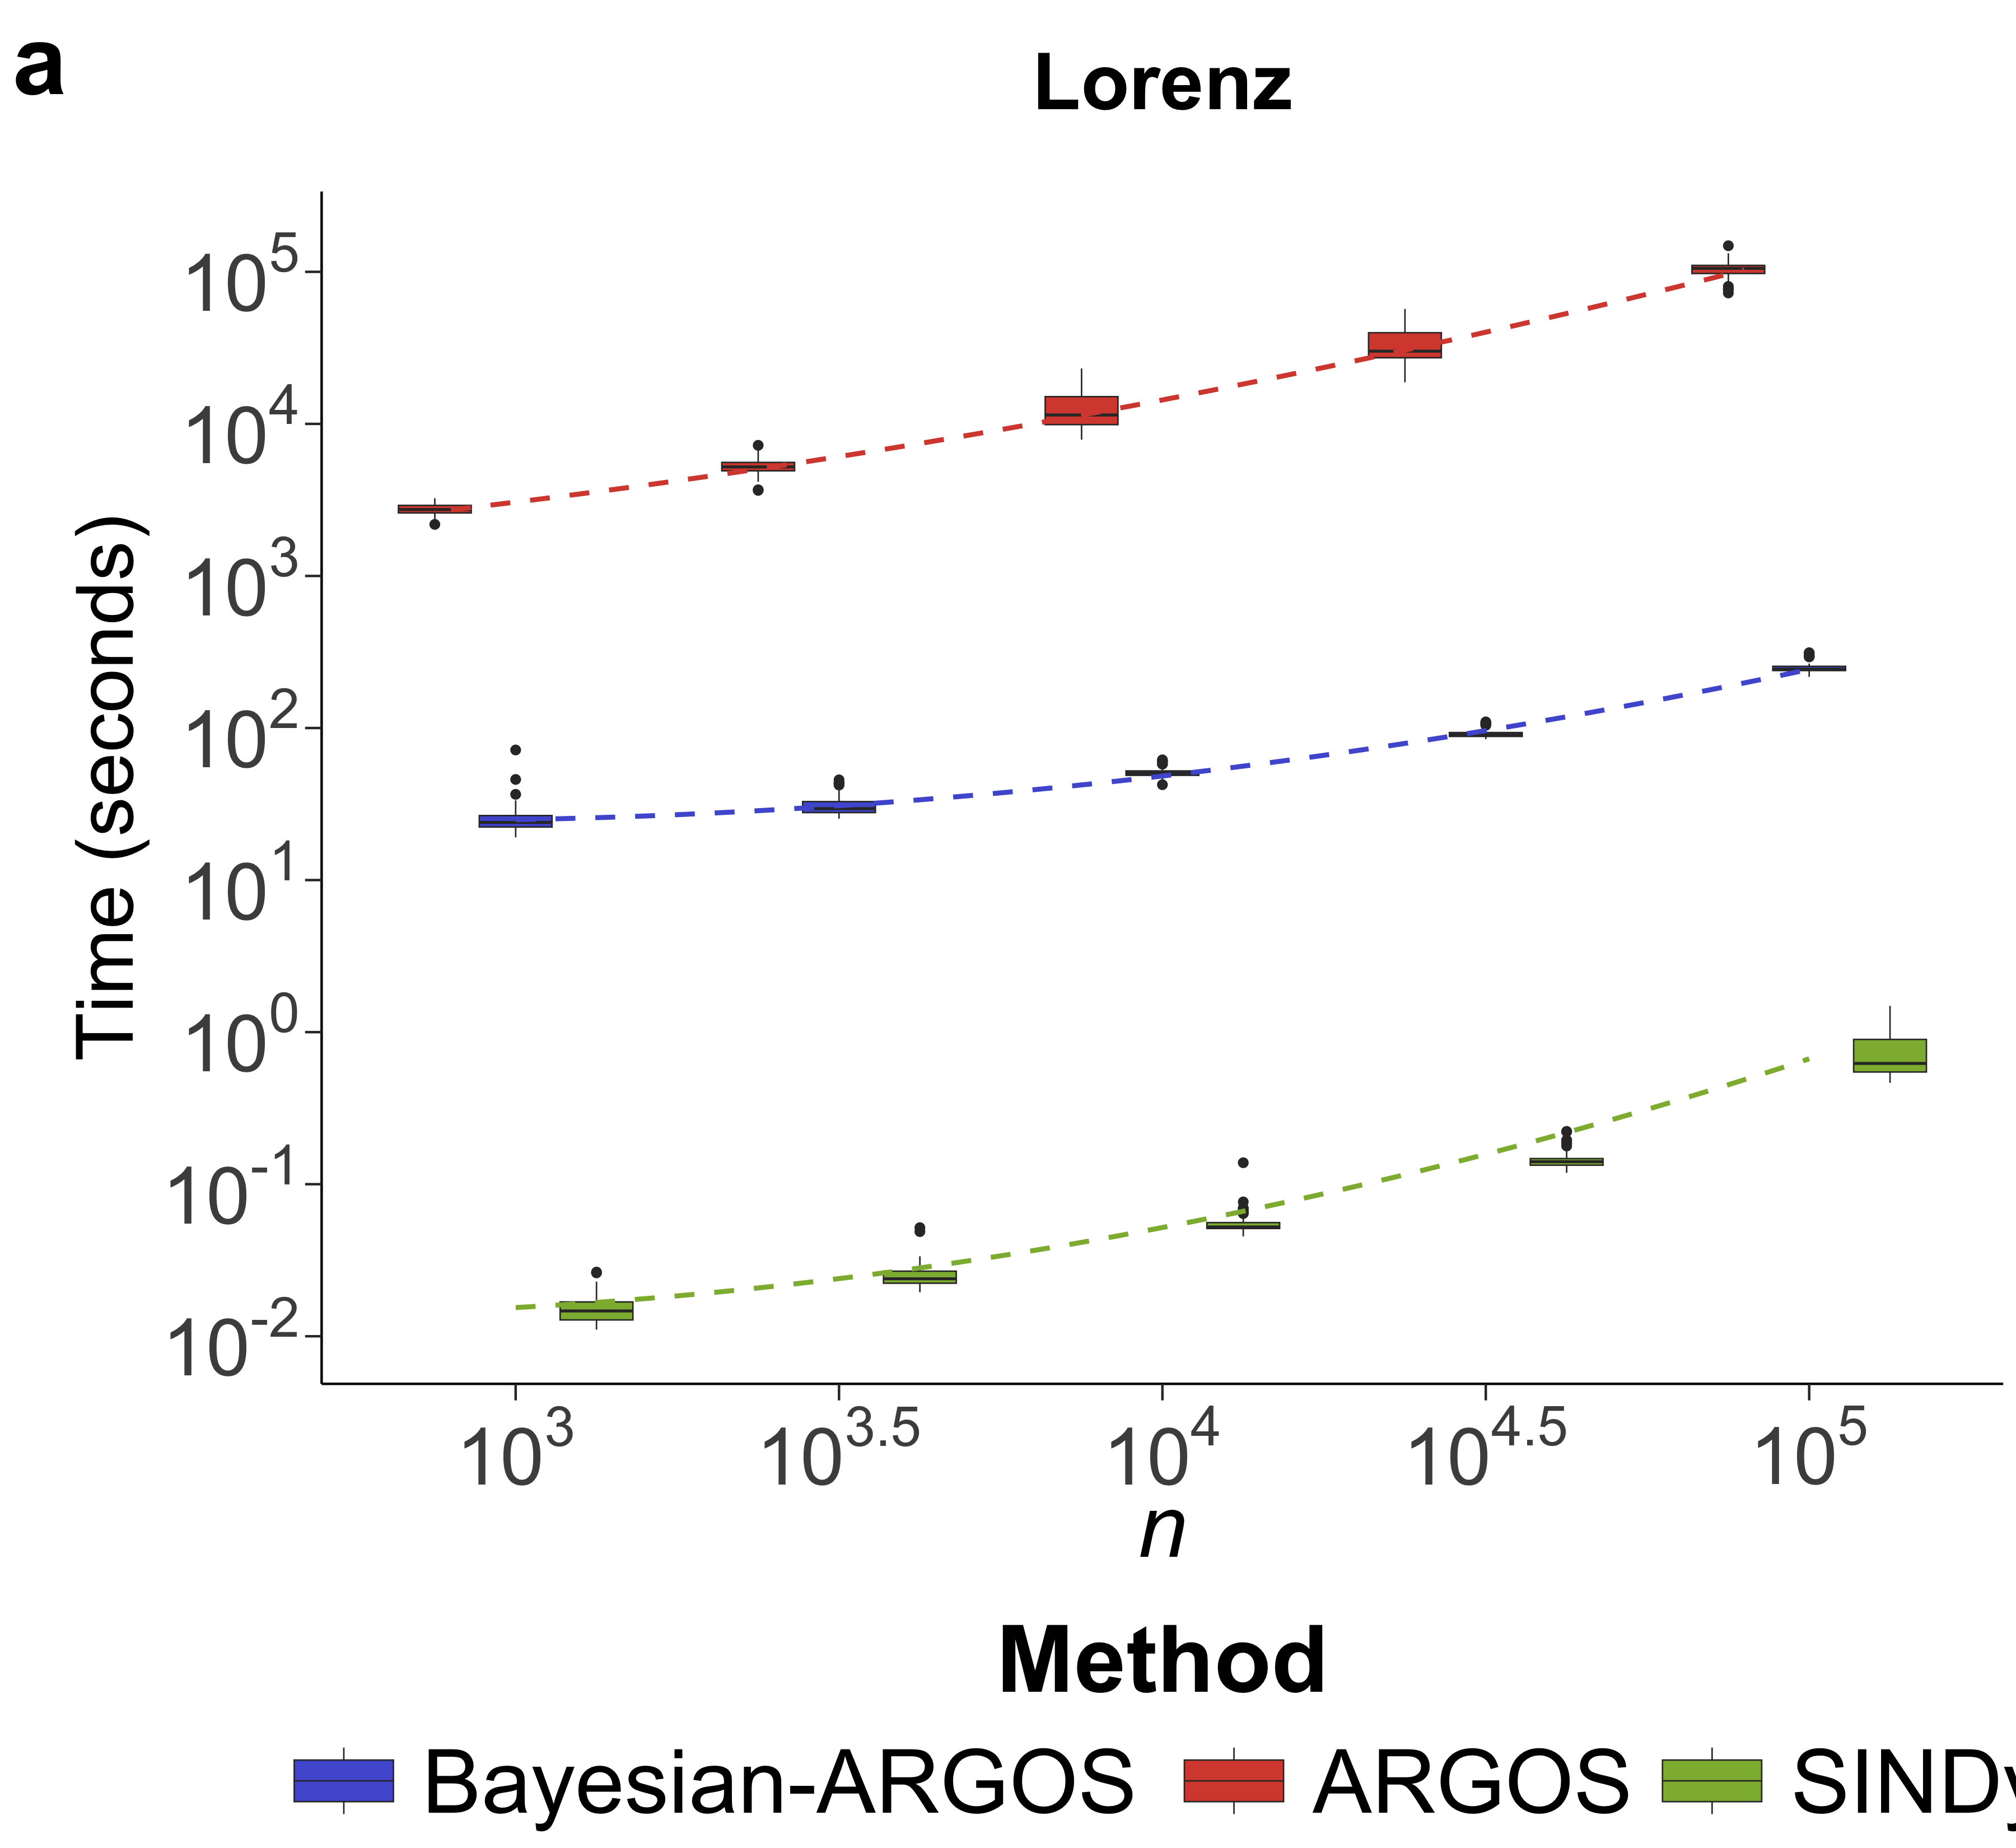

In [13]:
colors <- c(
    "Bayesian-ARGOS" = "#505ed5",
    "ARGOS" = "#d74d3d",
    "SINDy" = "#8eb63d",
    "#FA5524",
    "#EF60AD" # F0B823
)

legend_order <- c("Bayesian-ARGOS", "ARGOS", "SINDy")

x_labels <- c(
    expression(paste("10"^"3")),
    expression(paste("10"^"3.5")),
    expression(paste("10"^"4")),
    expression(paste("10"^"4.5")),
    expression(paste("10"^"5"))
)

y_breaks <- trans_breaks("log10", function(x) {
    10^x
})(c(
    min(methods_running_time_table$run_time),
    max(methods_running_time_table$run_time)
))
y_breaks <-
    y_labels <- pretty_breaks()(c(0, max(methods_running_time_table$run_time)))

breaks_log10 <- function(x) {
    low <- floor(log10(min(x)))
    high <- ceiling(log10(max(x)))

    10^(seq.int(low, high))
}

runtime_ggplot <-
    ggplot() +
    geom_boxplot(
        data = methods_running_time_table,
        aes(x = eta, y = run_time, fill = method),
        lwd = 0.3
    ) +
    geom_smooth(
        data = methods_running_time_table_argos,
        aes(x = eta - 0.2, y = run_time),
        method = "lm",
        formula = y ~ stats::poly(x, 2, raw = TRUE),
        alpha = 0.2,
        lty = 2,
        color = colors["ARGOS"],
        se = FALSE
    ) +
    geom_smooth(
        data = methods_running_time_table_bayesian_argos,
        aes(x = eta, y = run_time),
        method = "lm",
        formula = y ~ stats::poly(x, 2, raw = TRUE),
        alpha = 0.2,
        lty = 2,
        color = colors["Bayesian-ARGOS"],
        se = FALSE
    ) +
    geom_smooth(
        data = methods_running_time_table_sindy,
        aes(x = eta, y = run_time),
        method = "lm",
        formula = y ~ stats::poly(x, 2, raw = TRUE),
        alpha = 0.2,
        lty = 2,
        color = colors["SINDy"],
        se = FALSE
    ) +
    # annotate(
    #     geom = "text", x = 1, y = 3200,
    #     label = TeX("$\\sim 0.42(log_{10}n)^2$", output = "character"),
    #     parse = TRUE, size = 9
    # ) +
    # annotate(
    #     geom = "text", x = 1, y = 650,
    #     label = TeX("$\\sim 0.21(log_{10}n)^2$", output = "character"),
    #     parse = TRUE, size = 9
    # ) +
    # annotate(
    #     geom = "text", x = 2.5, y = 250,
    #     label = TeX("$\\sim 0.724(log10n)^2$", output = "character"),
    #     parse = TRUE, size = 9
    # ) +
    scale_y_log10(
        breaks = breaks_log10,
        labels = trans_format(log10, math_format(10^.x))
    ) +
    scale_x_discrete(
        drop = FALSE,
        labels = x_labels
    ) +
    labs(
        x = TeX("$\\textit{n}$"),
        y = "Time (seconds)",
        tag = "a",
        title = "Lorenz"
    ) +
    theme(
        axis.line = element_line(colour = "black"),
        axis.ticks.length = unit(.25, "cm"),
        panel.grid.major = element_blank(),
        panel.grid.minor = element_blank(),
        panel.border = element_blank(),
        panel.background = element_blank(),
        legend.key = element_blank(),
        legend.text = element_text(size = 32.5),
        # Changed for legend
        legend.title = element_text(face = "bold", size = 34),
        axis.text = element_text(size = 34),
        axis.title.x = element_text(size = 38),
        axis.title.y = element_text(
            size = 34,
            angle = 90,
            vjust = 0.5
        ),
        plot.title = element_text(
            size = 34,
            face = "bold",
            hjust = 0.5,
            vjust = 4
        ), # center title horizontally
        plot.tag = element_text(size = 42, face = "bold"), # vjust = -10,
        legend.position = "none",
        # legend.text.align = 0,
        # plot.margin = unit(c(-35, 0, 0, 0), "pt")
    ) +
    theme(
        legend.position = "bottom",
        legend.direction = "horizontal",
        legend.key.width = unit(2, "cm")
    ) +
    scale_fill_manual(name = "Method", values = colors, breaks = legend_order) +
    guides(
        fill = guide_legend(
            title.position = "top",
            title.hjust = 0.5,
            nrow = 1,
            byrow = TRUE,
            keywidth = unit(2, "cm"),
            title.theme = element_text(
                size = 40,
                face = "bold",
                margin = margin(b = 16)
            ),
            label.theme = element_text(size = 38)
        )
    )

runtime_ggplot

## Give the computational plot for another method


In [14]:
dynamical_system_name <- "thomas"
experiment_name_list <- list("argos-alasso", "bayesian-alasso-ro")
method_list <- list("argos-alasso", "bayesian-alasso-ro")
function_number <- 3
exp_n <- TRUE
typical_pattern <- "snr49"
num_init <- 100

In [15]:
total_results_summary_df <- enhance_total_results_summary_df(
    root_path = root_path,
    experiment_name_list = experiment_name_list,
    method_list = method_list,
    function_number = function_number,
    num_init = num_init,
    dynamical_system_name = dynamical_system_name,
    exp_n = exp_n,
    typical_pattern = typical_pattern
)
methods_running_time_table <- create_time_complexity_table(
    total_results_summary_df = total_results_summary_df,
    type_1_method_list = c("alasso"),
    type_1_method_cpu_number = 20,
    type_2_method_list = c("bayesian-argos", "bayesian-alasso-ro"),
    type_2_method_cpu_number = 4
)

[1] "/Users/yuzhengzhang/Documents-Local/Code-Local/Bayesian-ARGOS/Experiments/argos-alasso/thomas/results/thomas_1_e2_e3_bo2000_se100_alasso_ridge_snr49.RData"
[2] "/Users/yuzhengzhang/Documents-Local/Code-Local/Bayesian-ARGOS/Experiments/argos-alasso/thomas/results/thomas_1_e3_e4_bo2000_se100_alasso_ridge_snr49.RData"
[3] "/Users/yuzhengzhang/Documents-Local/Code-Local/Bayesian-ARGOS/Experiments/argos-alasso/thomas/results/thomas_1_e4_e5_bo2000_se100_alasso_ridge_snr49.RData"
[1] "/Users/yuzhengzhang/Documents-Local/Code-Local/Bayesian-ARGOS/Experiments/argos-alasso/thomas/results/thomas_2_e2_e3_bo2000_se100_alasso_ridge_snr49.RData"
[2] "/Users/yuzhengzhang/Documents-Local/Code-Local/Bayesian-ARGOS/Experiments/argos-alasso/thomas/results/thomas_2_e3_e4_bo2000_se100_alasso_ridge_snr49.RData"
[3] "/Users/yuzhengzhang/Documents-Local/Code-Local/Bayesian-ARGOS/Experiments/argos-alasso/thomas/results/thomas_2_e4_e5_bo2000_se100_alasso_ridge_snr49.RData"
[1] "/Users/yuzhengzhang/Documents

In [16]:
total_results_summary_df_sindy <- enhance_total_results_summary_df_py(
    root_path = pysindy_path,
    experiment_name_list = c("pysindy"),
    method_list = c("pysindy"),
    num_init = num_init,
    dynamical_system_name = dynamical_system_name,
    exp_n = exp_n,
    typical_pattern = typical_pattern
)
sindy_running_time_table <- create_time_complexity_table_py(
    total_results_summary_df = total_results_summary_df_sindy,
    type_1_method_list = c("alasso"),
    type_1_method_cpu_number = 20,
    type_2_method_list = c("bayesian-argos", "bayesian-alasso-ro"),
    type_2_method_cpu_number = 4,
    type_3_method_list = c("pysindy"),
    type_3_method_cpu_number = 1
)
total_running_time_table <- rbind(
    methods_running_time_table,
    sindy_running_time_table
)
total_running_time_table <- rename_method_names(total_running_time_table)
tail(total_running_time_table)

[1] "/Users/yuzhengzhang/Documents-Local/Code-Local/Bayesian-ARGOS/Pysindy/exp/thomas/results/thomas_e2_e3_se100_snr49.RData"
[2] "/Users/yuzhengzhang/Documents-Local/Code-Local/Bayesian-ARGOS/Pysindy/exp/thomas/results/thomas_e3_e4_se100_snr49.RData"
[3] "/Users/yuzhengzhang/Documents-Local/Code-Local/Bayesian-ARGOS/Pysindy/exp/thomas/results/thomas_e4_e5_se100_snr49.RData"
[1] 1
[1] 100
[1] 2
[1] 100
[1] 3
[1] 100
[1] 4
[1] 100
[1] 5
[1] 100
[1] 6
[1] 100
[1] 7
[1] 100
[1] 8
[1] 100
[1] 9
[1] 100
[1] 10
[1] 100
[1] 11
[1] 100
[1] 12
[1] 100
[1] 13
[1] 100
[1] 14
[1] 100
[1] 15
[1] 100
[1] 16
[1] 100
[1] 17
[1] 100
[1] 18
[1] 100
[1] 19
[1] 100
[1] 20
[1] 100
[1] 21
[1] 100
[1] 22
[1] 100
[1] 23
[1] 100
[1] 24
[1] 100
[1] 25
[1] 100
[1] 26
[1] 100
[1] 27
[1] 100
[1] 28
[1] 100
[1] 29
[1] 100
[1] 30
[1] 100
[1] 31
[1] 100


,n_running_id,run_time,eta,method
,<chr>,<dbl>,<chr>,<chr>
pysindy.3095,5-94,0.6380043,5,SINDy
pysindy.3096,5-95,0.5489397,5,SINDy
pysindy.3097,5-96,0.6424873,5,SINDy
pysindy.3098,5-97,0.5711007,5,SINDy
pysindy.3099,5-98,0.5634670,5,SINDy
pysindy.3100,5-99,0.5824413,5,SINDy


In [17]:
selected_eta_list <- seq(3, 5, by = 0.5)
methods_running_time_table <- total_running_time_table %>%
  dplyr::filter(eta %in% selected_eta_list)


methods_running_time_table_argos <- methods_running_time_table %>%
  dplyr::filter(method == "ARGOS")
methods_running_time_table_argos$eta <- as.numeric(
  methods_running_time_table_argos$eta
) *
  2 -
  5

methods_running_time_table_bayesian_argos <- methods_running_time_table %>%
  dplyr::filter(method == "Bayesian-ARGOS")
methods_running_time_table_bayesian_argos$eta <- as.numeric(
  methods_running_time_table_bayesian_argos$eta
) *
  2 -
  5

methods_running_time_table_sindy <- methods_running_time_table %>%
  dplyr::filter(method == "SINDy")
methods_running_time_table_sindy$eta <- as.numeric(
  methods_running_time_table_sindy$eta
) *
  2 -
  5

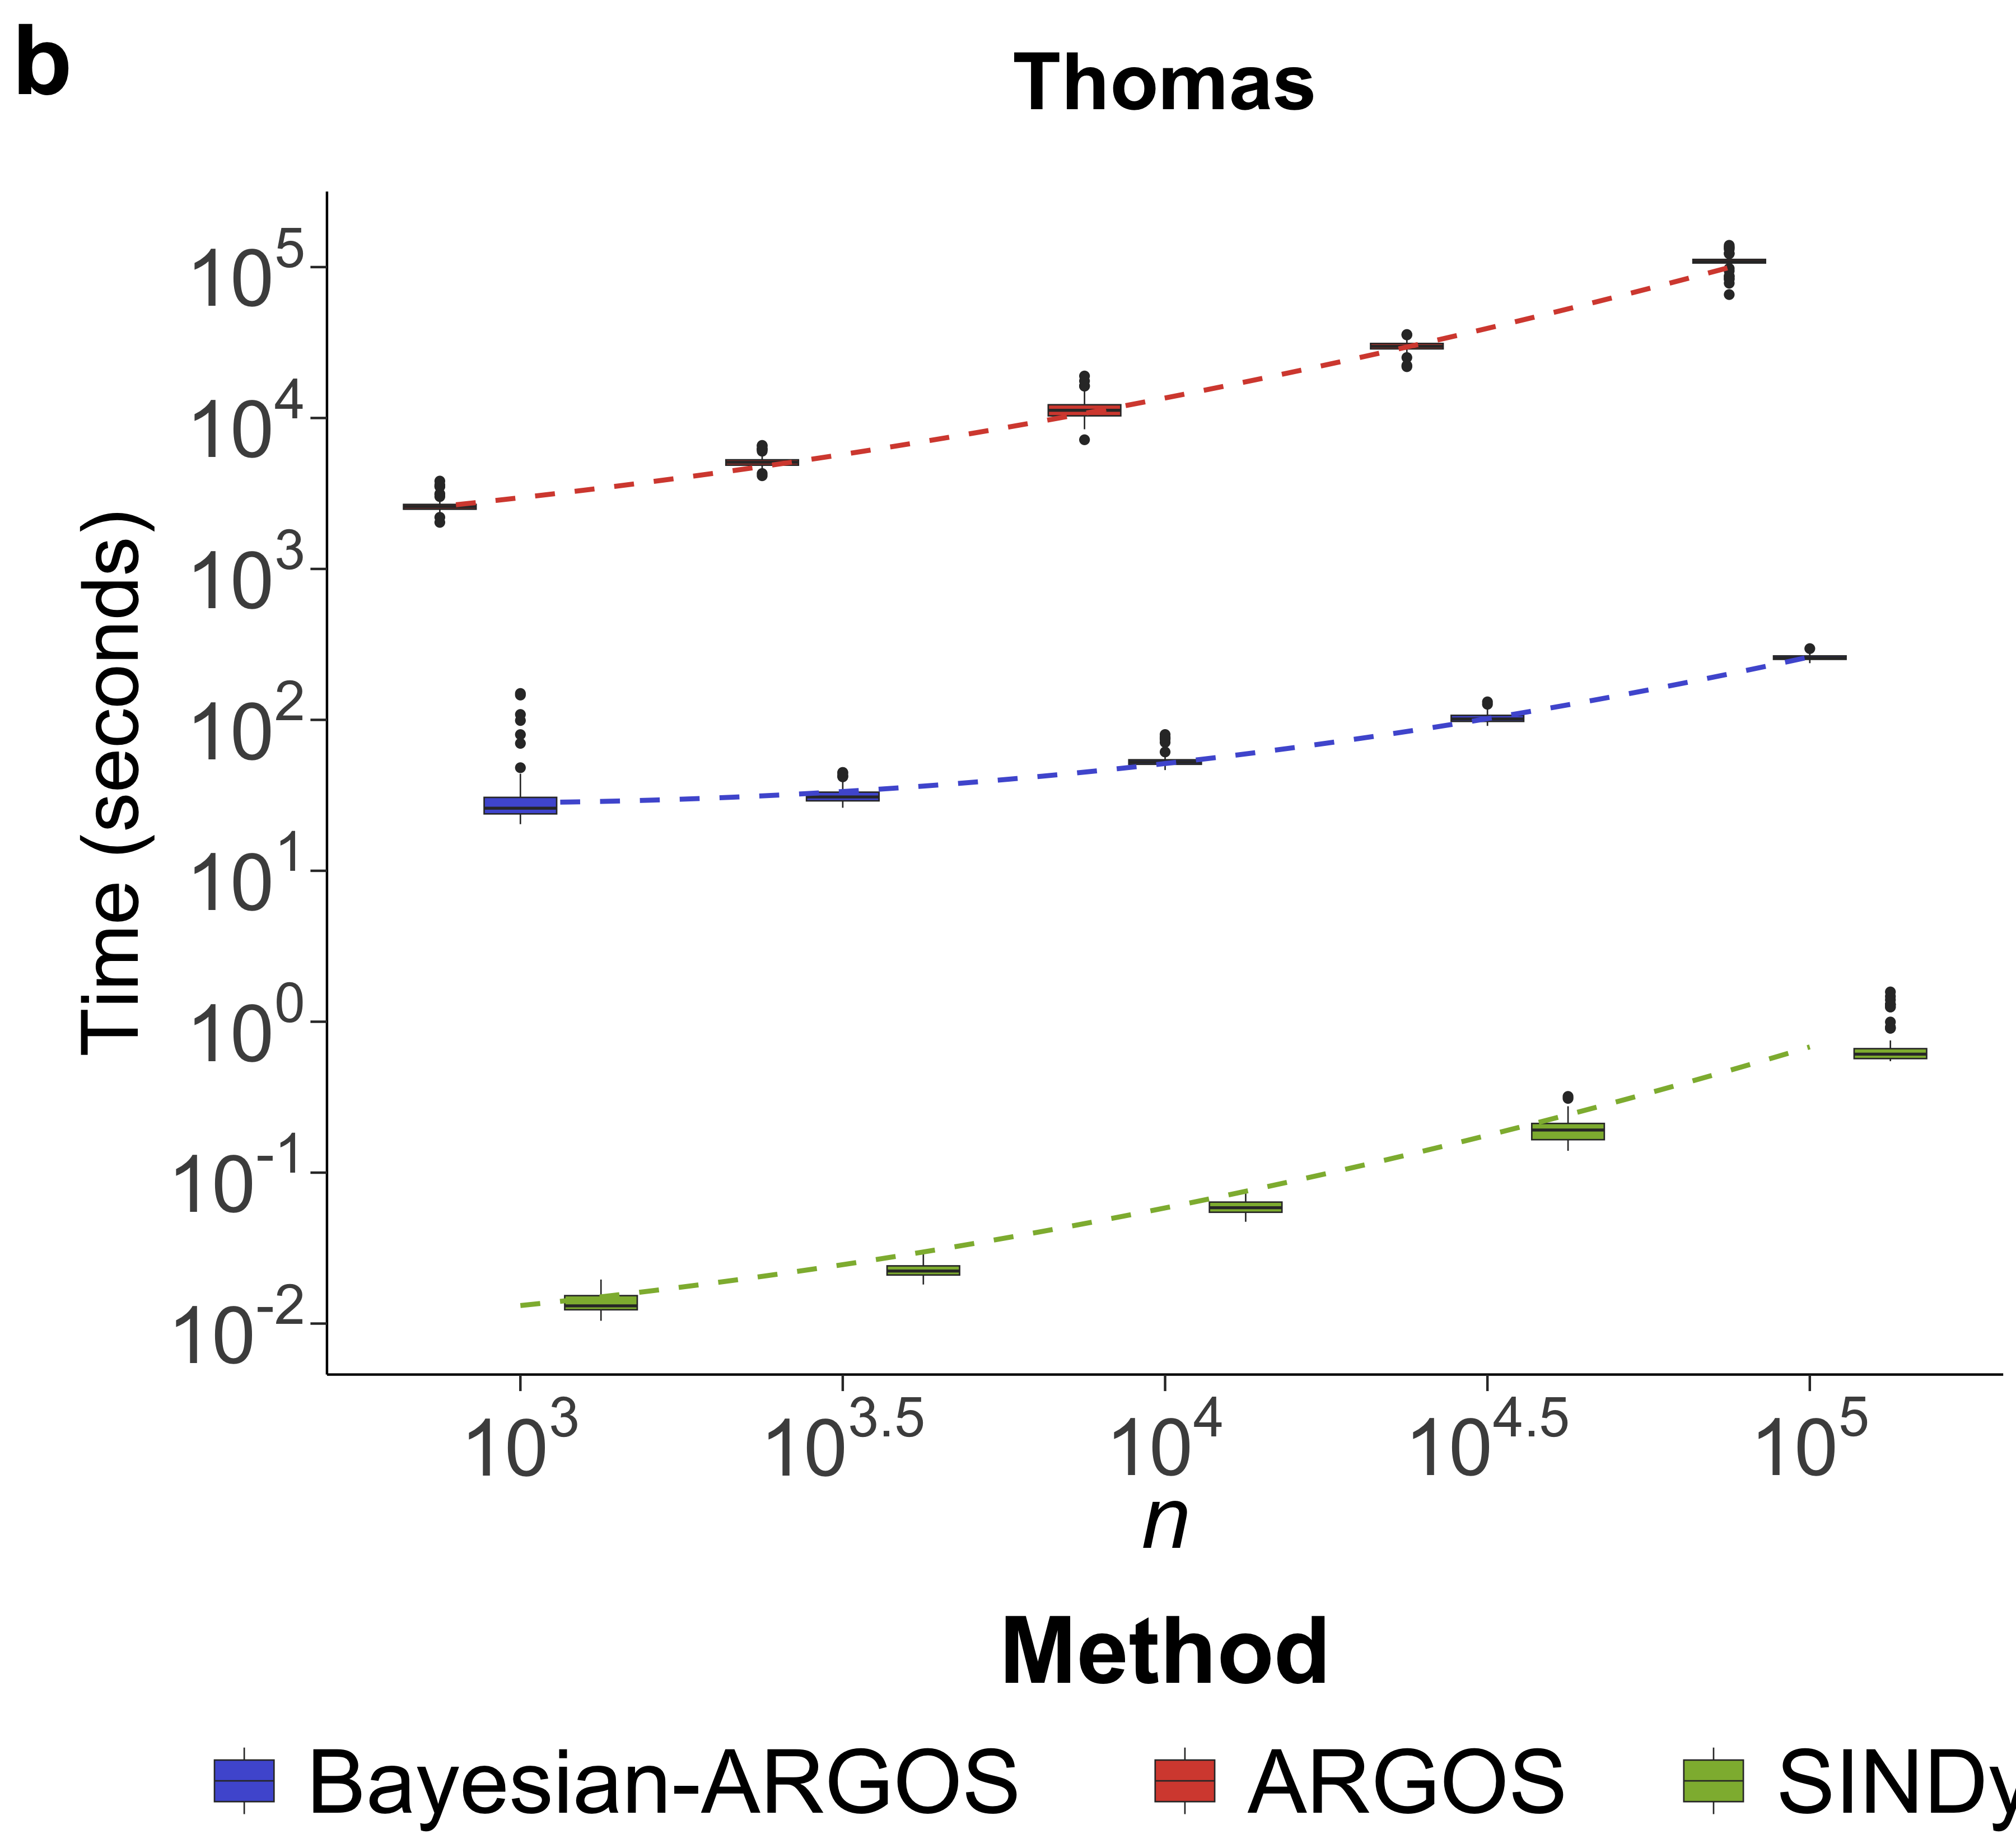

In [18]:
colors <- c(
    "Bayesian-ARGOS" = "#505ed5",
    "ARGOS" = "#d74d3d",
    "SINDy" = "#8eb63d",
    "#FA5524",
    "#EF60AD" # F0B823
)

legend_order <- c("Bayesian-ARGOS", "ARGOS", "SINDy")

x_labels <- c(
    expression(paste("10"^"3")),
    expression(paste("10"^"3.5")),
    expression(paste("10"^"4")),
    expression(paste("10"^"4.5")),
    expression(paste("10"^"5"))
)

y_breaks <- trans_breaks("log10", function(x) {
    10^x
})(c(
    min(methods_running_time_table$run_time),
    max(methods_running_time_table$run_time)
))
y_breaks <-
    y_labels <- pretty_breaks()(c(0, max(methods_running_time_table$run_time)))

breaks_log10 <- function(x) {
    low <- floor(log10(min(x)))
    high <- ceiling(log10(max(x)))

    10^(seq.int(low, high))
}

runtime_ggplot_2 <-
    ggplot() +
    geom_boxplot(
        data = methods_running_time_table,
        aes(x = eta, y = run_time, fill = method),
        lwd = 0.3
    ) +
    geom_smooth(
        data = methods_running_time_table_argos,
        aes(x = eta - 0.2, y = run_time),
        method = "lm",
        formula = y ~ stats::poly(x, 2, raw = TRUE),
        alpha = 0.2,
        lty = 2,
        color = colors["ARGOS"],
        se = FALSE
    ) +
    geom_smooth(
        data = methods_running_time_table_bayesian_argos,
        aes(x = eta, y = run_time),
        method = "lm",
        formula = y ~ stats::poly(x, 2, raw = TRUE),
        alpha = 0.2,
        lty = 2,
        color = colors["Bayesian-ARGOS"],
        se = FALSE
    ) +
    geom_smooth(
        data = methods_running_time_table_sindy,
        aes(x = eta, y = run_time),
        method = "lm",
        formula = y ~ stats::poly(x, 2, raw = TRUE),
        alpha = 0.2,
        lty = 2,
        color = colors["SINDy"],
        se = FALSE
    ) +
    # annotate(
    #     geom = "text", x = 1, y = 3200,
    #     label = TeX("$\\sim 0.42(log_{10}n)^2$", output = "character"),
    #     parse = TRUE, size = 9
    # ) +
    # annotate(
    #     geom = "text", x = 1, y = 650,
    #     label = TeX("$\\sim 0.21(log_{10}n)^2$", output = "character"),
    #     parse = TRUE, size = 9
    # ) +
    # annotate(
    #     geom = "text", x = 2.5, y = 250,
    #     label = TeX("$\\sim 0.724(log10n)^2$", output = "character"),
    #     parse = TRUE, size = 9
    # ) +
    scale_y_log10(
        breaks = breaks_log10,
        labels = trans_format(log10, math_format(10^.x))
    ) +
    scale_x_discrete(
        drop = FALSE,
        labels = x_labels
    ) +
    labs(
        x = TeX("$\\textit{n}$"),
        y = "Time (seconds)",
        tag = "b",
        title = "Thomas"
    ) +
    theme(
        axis.line = element_line(colour = "black"),
        axis.ticks.length = unit(.25, "cm"),
        panel.grid.major = element_blank(),
        panel.grid.minor = element_blank(),
        panel.border = element_blank(),
        panel.background = element_blank(),
        legend.key = element_blank(),
        legend.text = element_text(size = 32.5),
        # Changed for legend
        legend.title = element_text(face = "bold", size = 34),
        axis.text = element_text(size = 34),
        axis.title.x = element_text(size = 38),
        axis.title.y = element_text(
            size = 34,
            angle = 90,
            vjust = 0.5
        ),
        plot.title = element_text(
            size = 34,
            face = "bold",
            hjust = 0.5,
            vjust = 4
        ), # center title horizontally
        plot.tag = element_text(size = 42, face = "bold"), # vjust = -10,
        legend.position = "none",
        # legend.text.align = 0,
        # plot.margin = unit(c(-35, 0, 0, 0), "pt")
    ) +
    theme(
        legend.position = "bottom",
        legend.direction = "horizontal",
        legend.spacing.x = unit(1.2, "cm")
    ) +
    scale_fill_manual(name = "Method", values = colors, breaks = legend_order) +
    guides(
        fill = guide_legend(
            title.position = "top",
            title.hjust = 0.5,
            nrow = 1,
            byrow = TRUE,
            keywidth = unit(1.2, "cm"),
            title.theme = element_text(
                size = 40,
                face = "bold",
                margin = margin(b = 20)
            ),
            label.theme = element_text(
                size = 38,
                margin = margin(l = 10, r = 40)
            )
        )
    )
# scale_colour_manual(values = colors)

runtime_ggplot_2

In [ ]:
nbfigsize(
    width = 32,
    height = 16
)

Warning message in sprintf("./ResultsAnalysis/computation-time-plots/imgs/computational_time_plot.pdf", :
“one argument not used by format './ResultsAnalysis/computation-time-plots/imgs/computational_time_plot.pdf'”


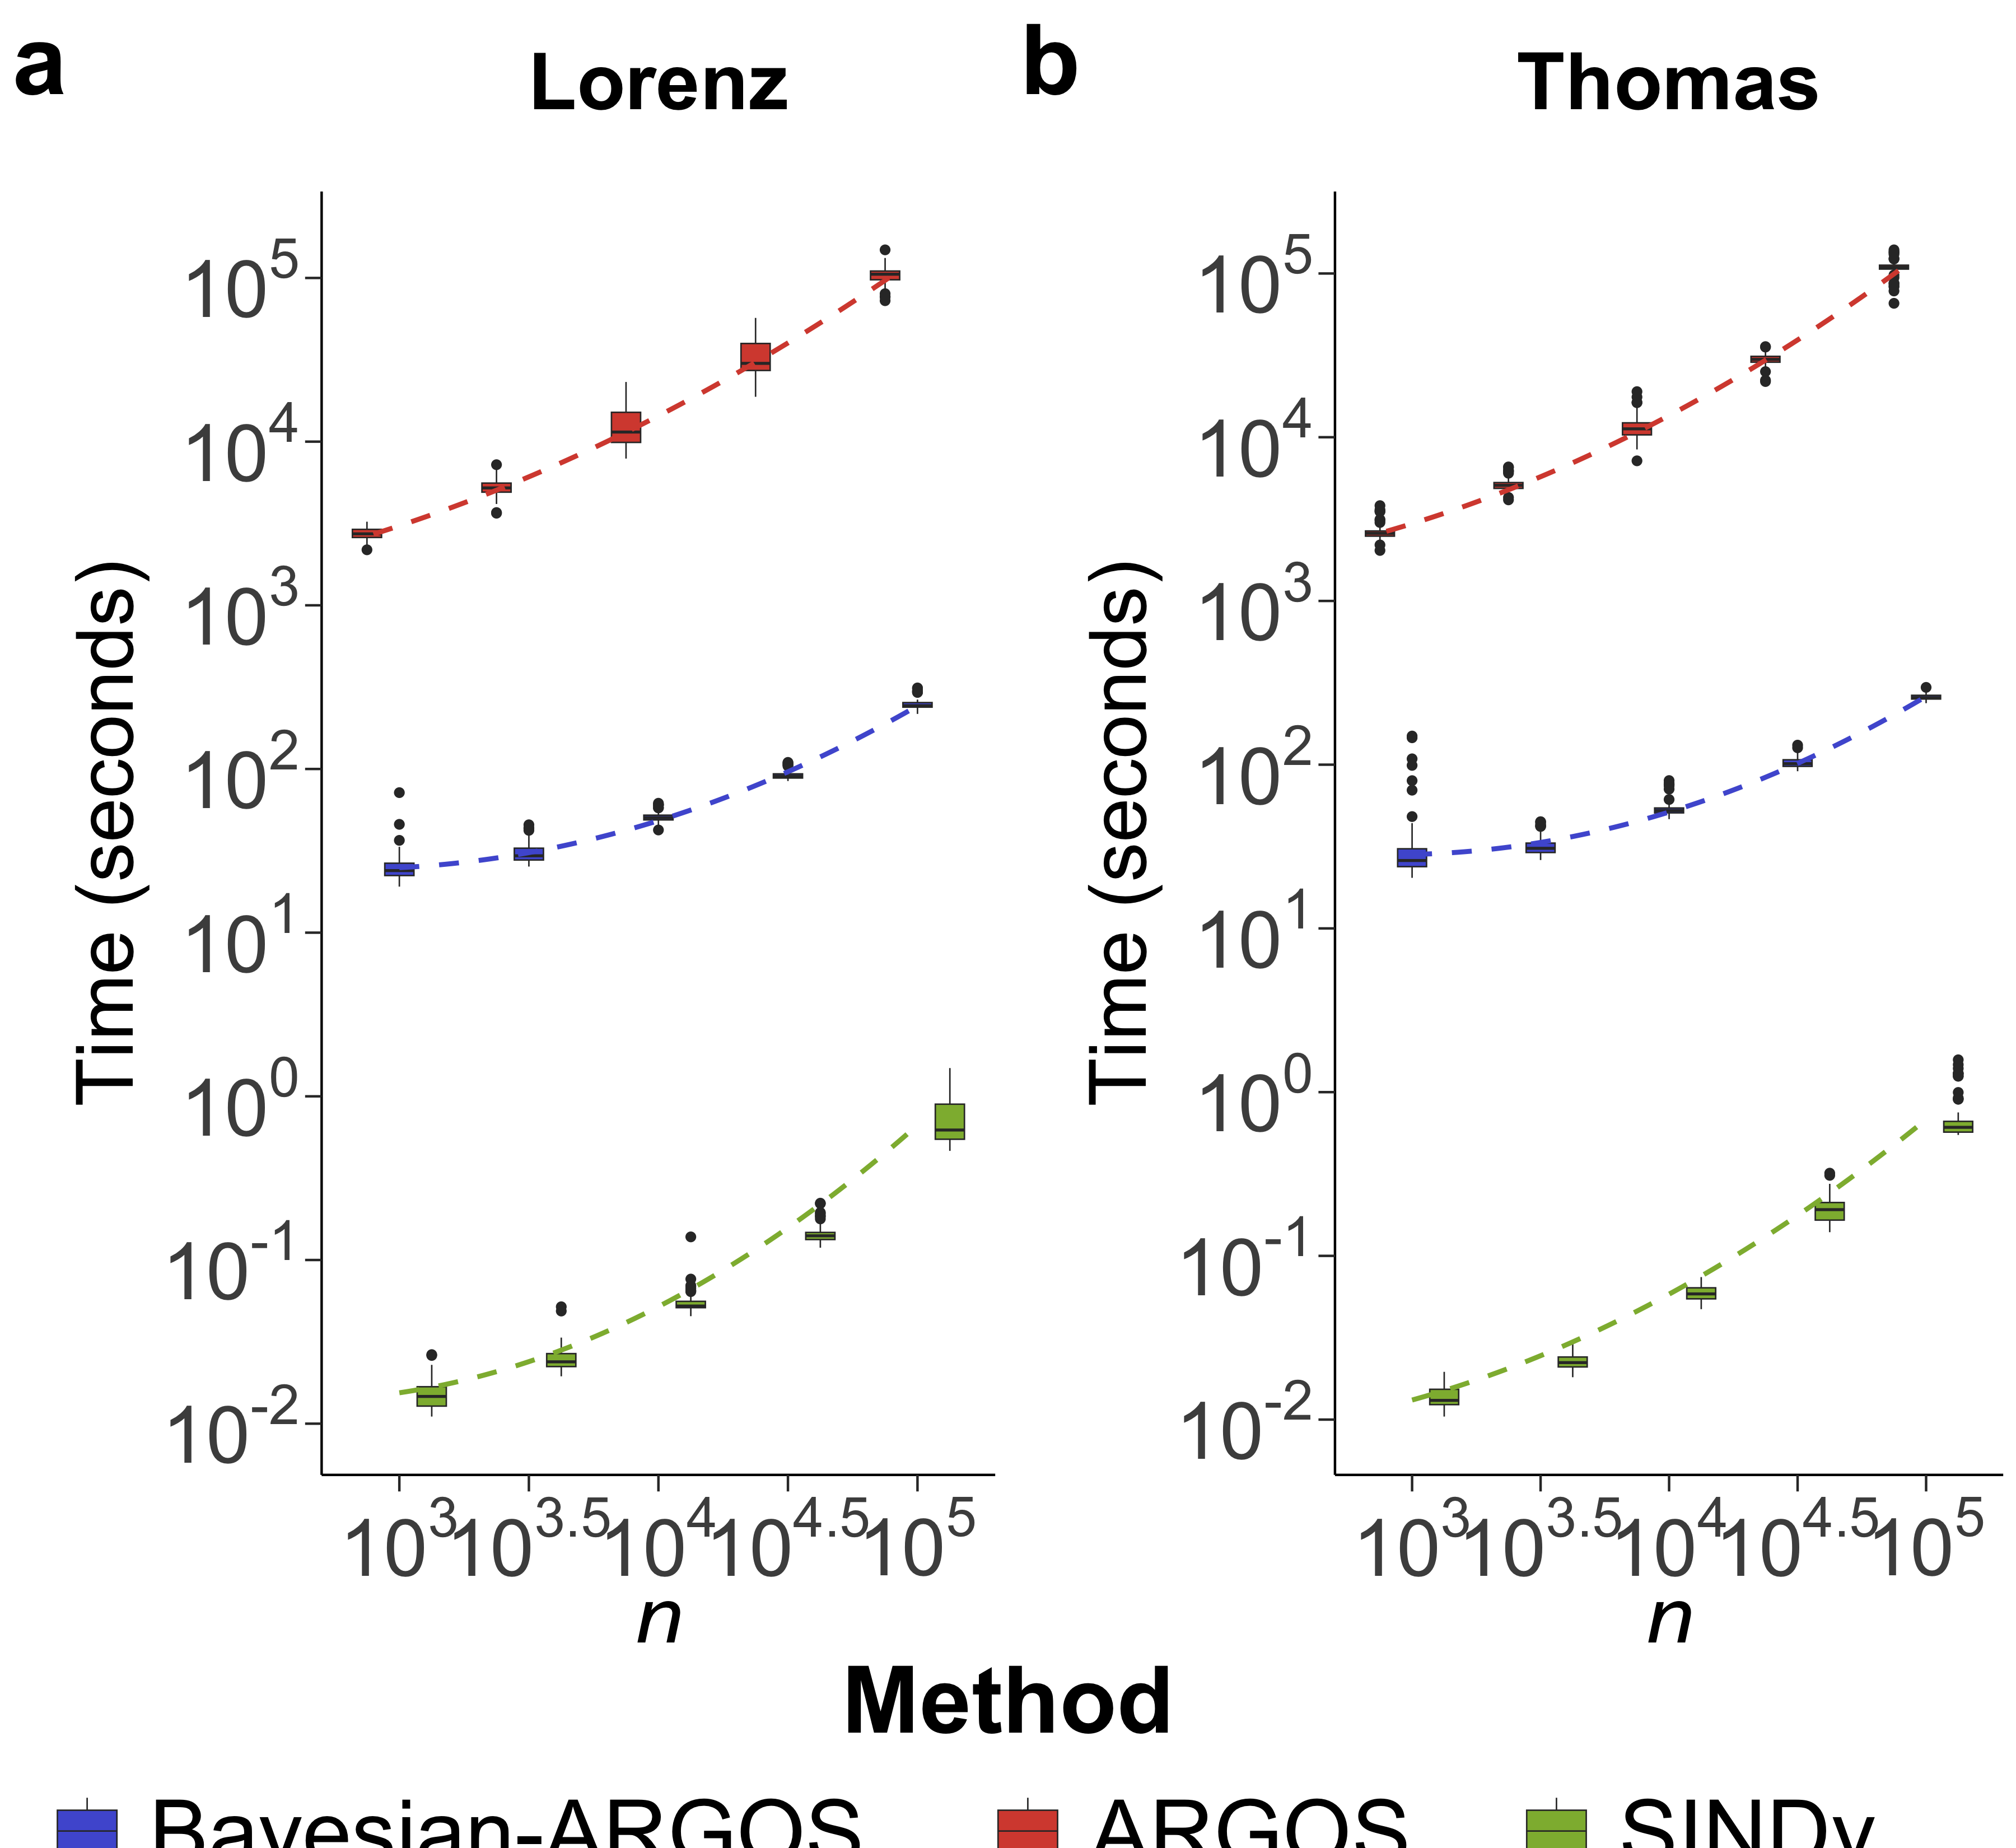

In [24]:
gglegend <- get_legend(runtime_ggplot_2)

runtime_comprehensive <-
    arrangeGrob(
        runtime_ggplot + theme(legend.position = "none"),
        runtime_ggplot_2 + theme(legend.position = "none"),
        nrow = 1
    )


runtime_comprehensive <- grid.arrange(
    runtime_comprehensive,
    gglegend,
    ncol = 1,
    heights = c(6, 0.6)
)

ggsave(
    plot = runtime_comprehensive,
    filename = sprintf(
        "./ResultsAnalysis/computation-time-plots/imgs/computational_time_plot.pdf",
        dynamical_system_name
    ),
    width = 28,
    height = 14,
    dpi = 300,
    units = "in"
)